<a href="https://colab.research.google.com/github/kaushalkalas-awesome/DKTE-TY-DL/blob/main/DL_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install kaggle

In [5]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:09<00:00, 252MB/s]



In [7]:
import zipfile
with zipfile.ZipFile('chest-xray-pneumonia.zip', 'r') as z:
    z.extractall('chest_xray')

print("Dataset Downloaded and Extracted!")

Dataset Downloaded and Extracted!


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2
import os
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [10]:
BASE_DIR   = 'chest_xray/chest_xray'

TRAIN_DIR  = os.path.join(BASE_DIR, 'train')
VAL_DIR    = os.path.join(BASE_DIR, 'val')
TEST_DIR   = os.path.join(BASE_DIR, 'test')

class_names = ['NORMAL', 'PNEUMONIA']

# Count images in each folder
def count_images(directory):
    counts = {}
    for cls in os.listdir(directory):
        cls_path = os.path.join(directory, cls)
        if os.path.isdir(cls_path):
            counts[cls] = len(os.listdir(cls_path))
    return counts

train_counts = count_images(TRAIN_DIR)
test_counts  = count_images(TEST_DIR)

print("=" * 50)
print("CHEST X-RAY DATASET INFO")
print("=" * 50)
print(f"Train : {train_counts}")
print(f"Test  : {test_counts}")
print(f"Classes : {class_names}")

CHEST X-RAY DATASET INFO
Train : {'PNEUMONIA': 3875, 'NORMAL': 1341}
Test  : {'PNEUMONIA': 390, 'NORMAL': 234}
Classes : ['NORMAL', 'PNEUMONIA']


In [11]:
IMG_SIZE   = 96
BATCH_SIZE = 32

# Data Augmentation for Training
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

# Only Rescale for Val and Test
test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255
)

# Load Train Data
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',        # NORMAL=0, PNEUMONIA=1
    color_mode='rgb',
    shuffle=True
)

# Load Val Data
val_gen = test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='rgb',
    shuffle=False
)

# Load Test Data
test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='rgb',
    shuffle=False
)

print(f"\nTrain batches : {len(train_gen)}")
print(f"Val batches   : {len(val_gen)}")
print(f"Test batches  : {len(test_gen)}")
print(f"Class indices : {train_gen.class_indices}")

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.

Train batches : 163
Val batches   : 1
Test batches  : 20
Class indices : {'NORMAL': 0, 'PNEUMONIA': 1}


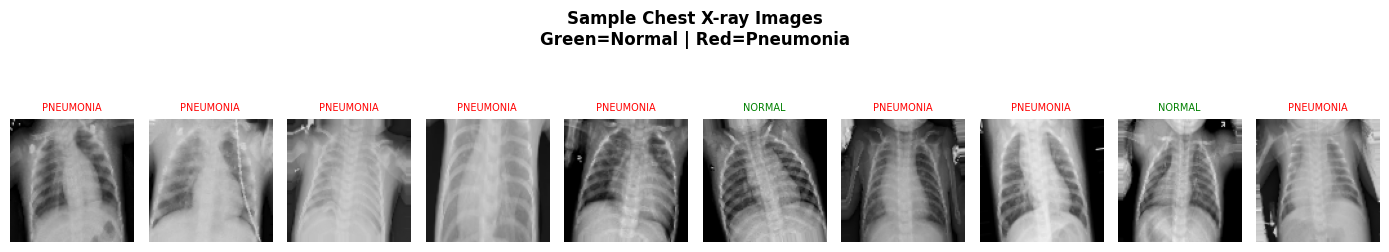

In [12]:
# Get one batch
sample_imgs, sample_lbls = next(iter(train_gen))

plt.figure(figsize=(14, 3))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(sample_imgs[i])
    label = class_names[int(sample_lbls[i])]
    color = 'red' if int(sample_lbls[i]) == 1 else 'green'
    plt.title(label, fontsize=7, color=color)
    plt.axis('off')
plt.suptitle('Sample Chest X-ray Images\n'
             'Green=Normal | Red=Pneumonia',
             fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
print("\nBuilding ResNet50 Model...")

base_model = tf.keras.applications.ResNet50(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze base
base_model.trainable = False

# Functional API (required for Grad-CAM)
inputs  = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x       = base_model(inputs, training=False)
x       = tf.keras.layers.GlobalAveragePooling2D(name='gap')(x)
x       = tf.keras.layers.Dense(128, activation='relu',
                                 name='dense1')(x)
x       = tf.keras.layers.Dropout(0.3, name='dropout')(x)
outputs = tf.keras.layers.Dense(1, activation='sigmoid',
                                 name='output')(x)

model = tf.keras.Model(inputs, outputs,
                       name='ResNet50_ChestXray')

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


Building ResNet50 Model...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "ResNet50_ChestXray"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 3, 3, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [18]:
print("\nTraining ResNet50 on Chest X-ray...")
history = model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    verbose=1
)


Training ResNet50 on Chest X-ray...
Epoch 1/10


ValueError: Attr 'Toutput_types' of 'OptionalFromValue' Op passed list of length 0 less than minimum 1.